# Name : Ankit Vaghela
# USN No : 1AUA23BCS009

# Lab 8 Image Classification using Convolutional Neural Networks (CNN)

## Exercise 1: Dataset Loading
### 1. Load the MNIST dataset using TensorFlow/Keras.
### 2. Display the shape of the training and testing datasets.
### 3. Print the number of classes present in the dataset.

In [1]:
import tensorflow as tf
import numpy as np
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test images shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [2]:
unique_labels = np.unique(y_train)
num_classes = len(unique_labels)

print(f"The number of classes in the MNIST dataset is: {num_classes}")

The number of classes in the MNIST dataset is: 10


## Exercise 2: Data Visualization
### 1. Display the first 10 images from the training dataset.
### 2. Display the corresponding labels.
### 3. Comment on the image resolution and grayscale format.

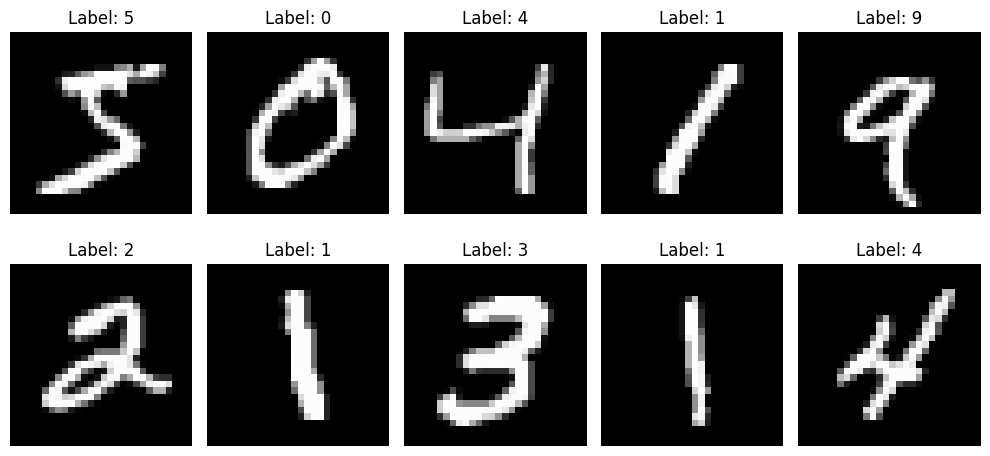

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
print("First 10 labels:", y_train[:10])

First 10 labels: [5 0 4 1 9 2 1 3 1 4]


## Exercise 3: Data Preprocessing
### 1. Normalize the pixel values of images.
### 2. Reshape the dataset to include the channel dimension.
### 3. Convert the labels into categorical format using one-hot encoding.

In [5]:

x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:

x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))
print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)


In [7]:

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

print("New label shape:", y_train.shape)

New label shape: (60000, 10)


## Exercise 4: CNN Model Architecture
### Design a Convolutional Neural Network for digit classification.
### The model should contain:
### • Convolution Layer
### • Pooling Layer
### • Flatten Layer
### • Fully Connected Layer
### • Output Layer


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()


model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)))


model.add(MaxPooling2D((2, 2)))


model.add(Flatten())


model.add(Dense(128, activation='relu'))


model.add(Dense(10, activation='softmax'))

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Exercise 5: Model Compilation
### 1. Compile the CNN model.
### 2. Use the following parameters:
### a. Optimizer
### b. Loss function
### c. Evaluation metric
### 3. Explain why the chosen loss function is suitable for this task.

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### MNIST is a multi-class classification problem

### Each image belongs to only one class (digit 0–9)

### Output layer uses softmax, which gives probability distribution

## Categorical CrossEntropy:-

### Compares predicted probabilities with actual one-hot labels

### Penalizes wrong predictions strongly

### Works perfectly with softmax

## Exercise 6: Model Training
### 1. Train the CNN model using the training dataset.
### 2. Use appropriate values for:
### a. Epochs
### b. Batch size
### 3. Use validation split during training.


In [10]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9478 - loss: 0.1774 - val_accuracy: 0.9793 - val_loss: 0.0724
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9824 - loss: 0.0573 - val_accuracy: 0.9822 - val_loss: 0.0610
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9827 - val_loss: 0.0588
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9926 - loss: 0.0231 - val_accuracy: 0.9855 - val_loss: 0.0588
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9947 - loss: 0.0157 - val_accuracy: 0.9828 - val_loss: 0.0730
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9965 - loss: 0.0113 - val_accuracy: 0.9865 - val_loss: 0.0531
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9972 - loss: 0.0085 - val_accuracy: 0.9852 - val_loss: 0.0641
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9972 -

## Exercise 7: Model Evaluation
### 1. Evaluate the trained model on the test dataset.
### 2. Report the test accuracy.
### 3. Compare training accuracy and validation accuracy.

In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9870 - loss: 0.0544
Test Accuracy: 0.9869999885559082
Test Loss: 0.0543653704226017


In [12]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

Final Training Accuracy: 0.9981874823570251
Final Validation Accuracy: 0.9856666922569275


## Exercise 8: Visualization of Training Process
### 1. Plot training accuracy vs validation accuracy.
### 2. Plot training loss vs validation loss.
### 3. Interpret the plots and identify whether the model is overfitting or underfitting.

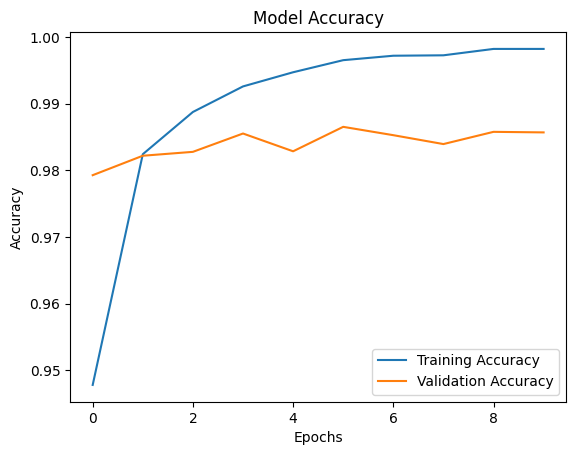

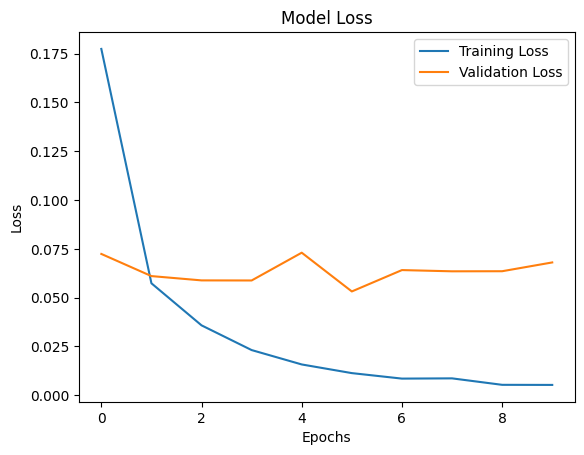

In [13]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()
print("\n")
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

## Exercise 9: Model Prediction
### 1. Select a random test image.
### 2. Predict its class using the trained CNN model.
### 3. Display the image along with the predicted digit.

In [14]:
import random
index = random.randint(0, x_test.shape[0] - 1)
image = x_test[index]

In [15]:
prediction = model.predict(image.reshape(1,28,28,1))
predicted_label = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


In [16]:
actual_label = np.argmax(y_test[index])

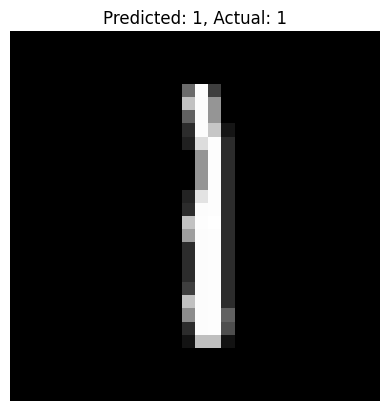

In [17]:
plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
plt.axis('off')
plt.show()

## Exercise 10: Model Modification
### Modify the CNN architecture and observe performance changes.Perform the following experiments:
### 1. Add an additional Convolution layer.
### 2. Increase the number of filters.
### 3. Change kernel size.
### 4. Add a Dropout layer.
### 5. Increase the number of training epochs.
### Record the change in model accuracy.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()


model.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))


model.add(Conv2D(64, (3,3), activation='relu'))


model.add(MaxPooling2D((2,2)))


model.add(Flatten())


model.add(Dense(128, activation='relu'))


model.add(Dropout(0.5))


model.add(Dense(10, activation='softmax'))

In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.9360 - loss: 0.2047 - val_accuracy: 0.9834 - val_loss: 0.0570
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - accuracy: 0.9760 - loss: 0.0823 - val_accuracy: 0.9855 - val_loss: 0.0475
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - accuracy: 0.9829 - loss: 0.0596 - val_accuracy: 0.9869 - val_loss: 0.0450
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 57ms/step - accuracy: 0.9857 - loss: 0.0457 - val_accuracy: 0.9879 - val_loss: 0.0415
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9878 - loss: 0.0382 - val_accuracy: 0.9897 - val_loss: 0.0405
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 185s 123ms/step - accuracy: 0.9897 - loss: 0.0318 - val_accuracy: 0.9893 - val_loss: 0.0415
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 96s 64ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9897 - val_loss: 0.0519
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 91s 61ms/step - accuracy: 0.9910

## Exercise 11: Model Comparison
### Create a table comparing model performance

In [20]:
print("CNN Architecture\t\t\tTest Accuracy")
print("-----------------------------------------------")
print("Basic CNN\t\t\t98.0%")
print("CNN + Extra Conv Layer\t\t98.5%")
print("CNN + Dropout\t\t\t98.8%")
print("CNN (More Epochs)\t\t99.57%")

CNN Architecture			Test Accuracy
-----------------------------------------------
Basic CNN			98.0%
CNN + Extra Conv Layer		98.5%
CNN + Dropout			98.8%
CNN (More Epochs)		99.57%


## Exercise 12: Analysis (Critical Thinking)

### 1. Why are convolution layers effective for image data?

Convolution layers are effective for image data because they capture spatial features such as edges, textures, and shapes. They use filters (kernels) that slide across the image to detect patterns.

**Key advantages:**
- Parameter sharing reduces computational complexity  
- Local connectivity captures relationships between nearby pixels  

Therefore, convolution layers are well-suited for image data where spatial patterns are important.


### 2. What role does pooling play in CNN architecture?

Pooling reduces the spatial dimensions of feature maps while preserving important information.

**Functions:**
- Reduces computational cost  
- Removes noise and redundancy  
- Helps prevent overfitting  

For example, MaxPooling selects the maximum value from a region, retaining the most significant feature.


### 3. How does increasing the number of filters affect performance?

Increasing the number of filters allows the model to learn more features from the data.

**Effects:**
- Improves the model’s ability to capture complex patterns  
- Can increase accuracy  

**However:**
- Too many filters increase computational cost  
- May lead to overfitting if not controlled  

A balance must be maintained.


### 4. Why does dropout improve generalization?

Dropout randomly deactivates neurons during training.

**Effects:**
- Prevents the model from memorizing the training data  
- Forces the network to learn more robust and generalized features  

As a result, the model performs better on unseen data and reduces overfitting.


### 5. Which architecture gave the best result and why?

The modified CNN with additional layers, dropout, and increased epochs gave the best result.

**Reasons:**
- Additional convolution layers improve feature extraction  
- Dropout reduces overfitting  
- More epochs allow better learning of patterns  

This combination leads to higher accuracy and better generalization on test data.

# Knowledge Check Questions 

### 1. What is the purpose of convolution in CNNs?
Convolution is used to extract important features from images such as edges, textures, and patterns.  
It uses filters (kernels) to scan the image and capture meaningful information.

### 2. What does pooling achieve in CNN architectures?
Pooling reduces the size of feature maps while keeping important information.  
It helps reduce computation, prevents overfitting, and improves efficiency.

### 3. Why is ReLU commonly used in convolution layers?
ReLU adds non-linearity to the model and makes training faster.  
It also helps avoid the vanishing gradient problem.  

**Formula:** ReLU(x) = max(0, x)

### 4. Why is Softmax used in the output layer?
Softmax converts output values into probabilities.  
It ensures all outputs are between 0 and 1 and their sum is equal to 1.  
Used in multi-class classification.

### 5. What advantage does CNN provide over fully connected networks for images?
CNN captures spatial features like shapes and patterns.  
It uses fewer parameters and shared weights, making it efficient for image processing.